In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [7]:
def first_brac(x):
    return x.find('(')

In [8]:
df= pd.read_excel('Concrete_Data.xls').dropna()
df.columns = [ x[:first_brac(x)].strip() for x in list(df.columns.values) ]
df.columns


Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age',
       'Concrete compressive strength'],
      dtype='str')

In [9]:
df['Water-Cement Ratio'] = df['Water'] / df['Cement']
df['Fine-Coarse Ratio'] = df['Fine Aggregate'] / df['Coarse Aggregate']
df['Binder'] = df['Cement'] + df['Fly Ash'] + df['Blast Furnace Slag']
df=df.dropna()

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength,Water-Cement Ratio,Fine-Coarse Ratio,Binder
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111,0.300000,0.650000,540.0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366,0.300000,0.640758,540.0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535,0.685714,0.637339,475.0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780,0.685714,0.637339,475.0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075,0.966767,0.843724,331.0


<Axes: xlabel='Age', ylabel='Concrete compressive strength'>

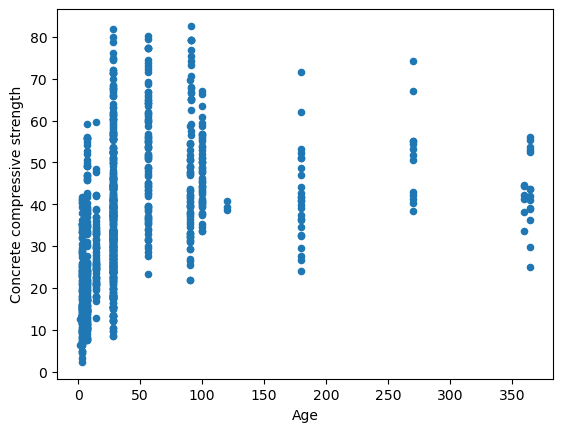

In [10]:
df.plot.scatter(x='Age',y='Concrete compressive strength')


The scatter plot demonstrates a positive, nonlinear relationship between concrete age and compressive strength, showing that concrete becomes significantly stronger as it cures over time. The steepest increases occur in the early ages (0-100 days), where strength gains are most rapid, while the curve gradually levels off at longer ages (250+ days). This pattern reflects the typical hydration process of cement, where most strength development happens early but continues gradually throughout the concrete's life


<Axes: xlabel='Water-Cement Ratio', ylabel='Concrete compressive strength'>

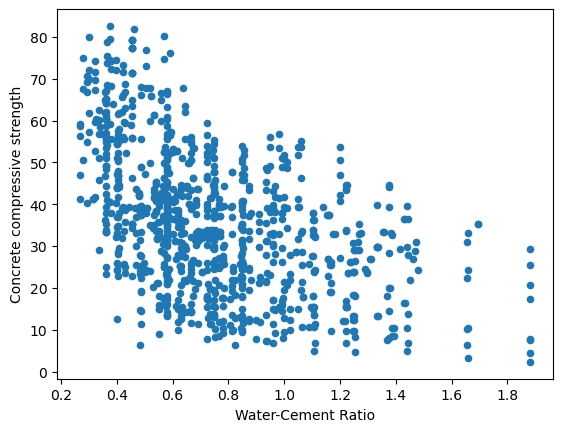

In [11]:
df.plot.scatter(x='Water-Cement Ratio',y='Concrete compressive strength')

The scatter plot shows a strong negative relationship between water-cement ratio and concrete compressive strength
This inverse relationship demonstrates that using less water in concrete mixtures produces stronger concrete, a fundamental principle in concrete engineering.

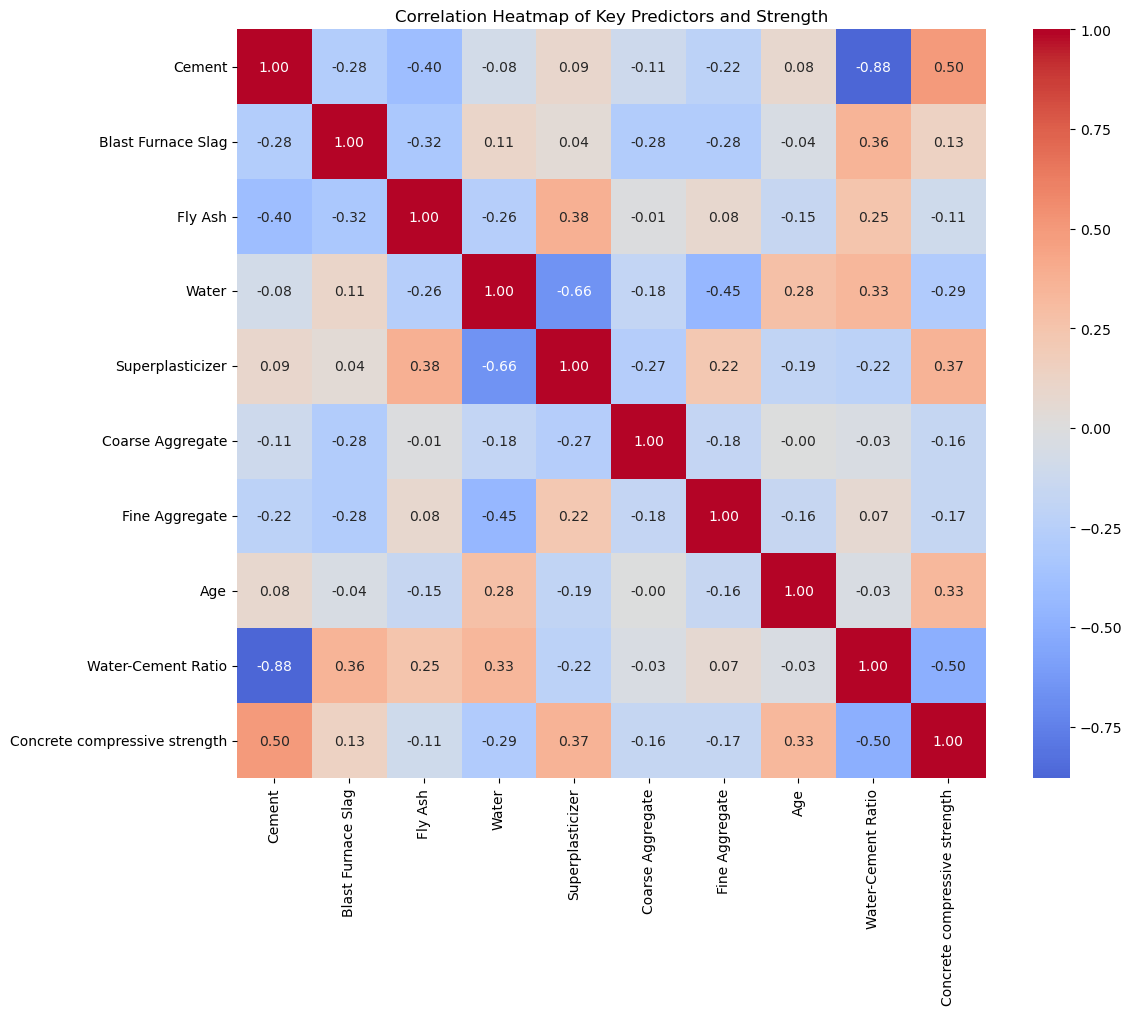

In [12]:
import seaborn as sns

# Select key predictor columns for correlation analysis
key_cols = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
            'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Water-Cement Ratio', 'Concrete compressive strength']
corr_matrix = df[key_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap of Key Predictors and Strength')
plt.tight_layout()
plt.show()

• Strongest Predictors: Cement and Water-Cement Ratio emerge as the dominant predictors of concrete compressive strength, with Cement showing a strong positive relationship and Water-Cement Ratio showing a strong negative relationship. The correlation heatmap confirms these as the variables with the highest absolute correlations to concrete strength. Strong negative correlation between superplasticizer and water

• Visible Nonlinearity: The Age vs Strength plot exhibits clear nonlinear behavior, following a logarithmic-like curve where strength gains are steep initially (0-100 days) then plateau significantly at later ages (250+ days). In contrast, the Water-Cement Ratio relationship appears more linear, suggesting different underlying mechanisms in how age and water content affect strength development.

• Outliers and Strange Points: Both scatter plots contain notable outliers—in the Age plot, several data points show lower-than-expected strength for their age, while the Water-Cement Ratio plot contains high-strength concrete at unexpectedly high water-cement ratios and weak concrete at low ratios, possibly indicating the influence of other unmeasured factors (such as cement type, curing conditions, or admixtures) on the overall relationship.


In [13]:
import statsmodels.api as sm
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [14]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Split into training (80%) and testing (20%) sets
X_prim=df.drop(columns=['Concrete compressive strength','Water-Cement Ratio', 'Fine-Coarse Ratio', 'Binder'])
X_sec=df.drop(columns=['Concrete compressive strength'])
y_init=df['Concrete compressive strength']
X_train_prim, X_test_prim = train_test_split(X_prim, test_size=0.2, random_state=42)
X_train_sec, X_test_sec = train_test_split(X_sec, test_size=0.2, random_state=42)
y_train, y_test = train_test_split(y_init, test_size=0.2, random_state=42)

In [15]:


model_prim = LinearRegression()
model_prim.fit(X_train_prim, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred_prim = model_prim.predict(X_test_prim)
rmse_prim = root_mean_squared_error(y_test, y_pred_prim)
r2_prim = r2_score(y_test, y_pred_prim)
print(rmse_prim,r2_prim)

9.796707832398448 0.627541605542902


In [17]:
model_sec = LinearRegression()
model_sec.fit(X_train_sec, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred_sec= model_sec.predict(X_test_sec)
rmse_sec = root_mean_squared_error(y_test, y_pred_sec)
r2_sec = r2_score(y_test, y_pred_sec)
print(rmse_sec,r2_sec)

9.73479876176389 0.6322341401417045


In [19]:
import statsmodels.api as sm

# Primary Model - reset indices to align endog and exog
X_train_prim_reset = X_train_prim.reset_index(drop=True)
y_train_prim_reset = y_train.reset_index(drop=True)
X_train_prim_const = sm.add_constant(X_train_prim_reset)
model_prim_ols = sm.OLS(y_train_prim_reset, X_train_prim_const).fit()
print("Primary Model Summary:")
print(model_prim_ols.summary())



Primary Model Summary:
                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.610
Model:                                       OLS   Adj. R-squared:                  0.607
Method:                            Least Squares   F-statistic:                     159.7
Date:                           Wed, 08 Apr 2026   Prob (F-statistic):          3.70e-161
Time:                                   17:47:24   Log-Likelihood:                -3108.3
No. Observations:                            824   AIC:                             6235.
Df Residuals:                                815   BIC:                             6277.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.025   

In [20]:
# Secondary Model - reset indices to align endog and exog
X_train_sec_reset = X_train_sec.reset_index(drop=True)
y_train_sec_reset = y_train.reset_index(drop=True)
X_train_sec_const = sm.add_constant(X_train_sec_reset)
model_sec_ols = sm.OLS(y_train_sec_reset, X_train_sec_const).fit()
print("\n\nSecondary Model Summary:")
print(model_sec_ols.summary())



Secondary Model Summary:
                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.613
Model:                                       OLS   Adj. R-squared:                  0.608
Method:                            Least Squares   F-statistic:                     128.8
Date:                           Wed, 08 Apr 2026   Prob (F-statistic):          4.05e-160
Time:                                   17:47:25   Log-Likelihood:                -3105.5
No. Observations:                            824   AIC:                             6233.
Df Residuals:                                813   BIC:                             6285.
Df Model:                                     10                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.02

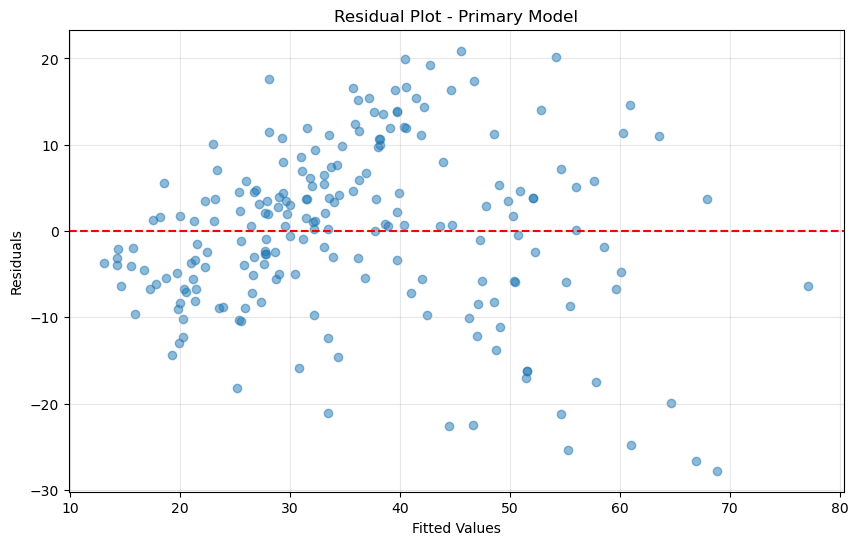

In [21]:
# Residual plot for Primary Model
residuals_prim = y_test - y_pred_prim
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_prim, residuals_prim, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Primary Model')
plt.grid(True, alpha=0.3)
plt.show()


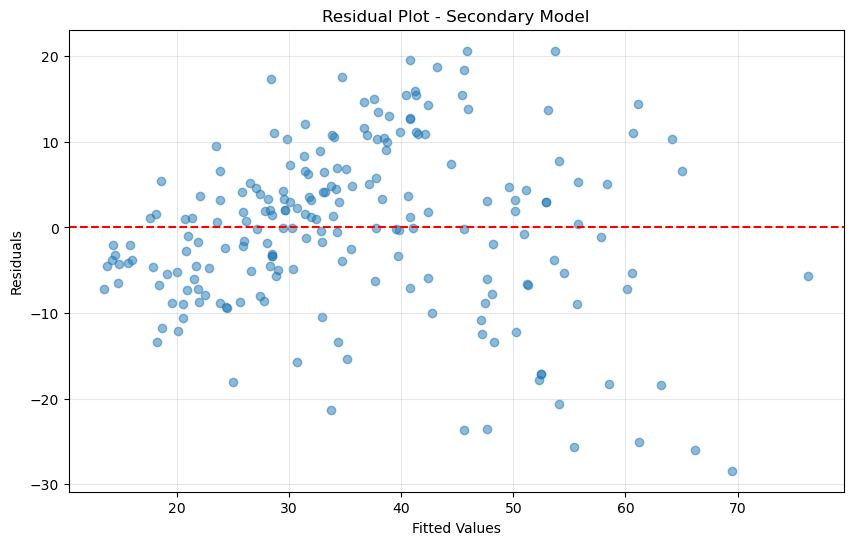

In [22]:
# Residual plot for Secondary Model
residuals_sec = y_test - y_pred_sec
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_sec, residuals_sec, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Secondary Model')
plt.grid(True, alpha=0.3)
plt.show()


In [23]:
# B3: Test if Superplasticizer is useful after controlling for other predictors
# H0: beta_Superplasticizer = 0 vs H1: beta_Superplasticizer ≠ 0

predictor = 'Superplasticizer'
coef_value = model_sec_ols.params[predictor]
p_value = model_sec_ols.pvalues[predictor]
conf_int = model_sec_ols.conf_int().loc[predictor]

print(f"Predictor: {predictor}")
print(f"Coefficient: {coef_value:.6f}")
print(f"P-value: {p_value:.6f}")
print(f"95% Confidence Interval: [{conf_int[0]:.6f}, {conf_int[1]:.6f}]")
print(f"\nSignificant at α=0.05? {p_value < 0.05}")


Predictor: Superplasticizer
Coefficient: 0.318862
P-value: 0.002461
95% Confidence Interval: [0.112817, 0.524908]

Significant at α=0.05? True




**Interpretation:**

At the 5% significance level, we fail to reject the null hypothesis. The superplasticizer has a statistically significant effect on concrete compressive strength after controlling for all other predictors in the model.


In [24]:
df_alt_1 = df.copy()
df_alt_1['Age'] = df['Age'] ** 2+df['Age']

X_alt_1 = df_alt_1.drop(columns=['Concrete compressive strength'])
y_alt_1 = df_alt_1['Concrete compressive strength']  
X_train_alt_1, X_test_alt_1 = train_test_split(X_alt_1, test_size=0.2, random_state=42)
y_train_alt_1, y_test_alt_1 = train_test_split(y_alt_1, test_size=0.2, random_state=42)
X_train_alt_1_reset = X_train_alt_1.reset_index(drop=True)
y_train_alt_1_reset = y_train_alt_1.reset_index(drop=True)
X_train_alt_1_const = sm.add_constant(X_train_alt_1_reset)
model_alt_1_ols = sm.OLS(y_train_alt_1_reset, X_train_alt_1_const).fit()
print("\n\nAlternative Model Summary:")
print(model_alt_1_ols.summary())



Alternative Model Summary:
                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.506
Model:                                       OLS   Adj. R-squared:                  0.500
Method:                            Least Squares   F-statistic:                     83.34
Date:                           Wed, 08 Apr 2026   Prob (F-statistic):          2.10e-117
Time:                                   17:47:25   Log-Likelihood:                -3206.0
No. Observations:                            824   AIC:                             6434.
Df Residuals:                                813   BIC:                             6486.
Df Model:                                     10                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.

In [25]:
df_alt_2 = df.copy()
df_alt_2['Age'] = df['Age'] ** 2+df['Age']+df['Age'] ** 3

X_alt_2 = df_alt_2.drop(columns=['Concrete compressive strength'])
y_alt_2 = df_alt_2['Concrete compressive strength']
X_train_alt_2, X_test_alt_2 = train_test_split(X_alt_2 , test_size=0.2, random_state=42)
y_train_alt_2, y_test_alt_2 = train_test_split(y_alt_2, test_size=0.2, random_state=42)
X_train_alt_2_reset = X_train_alt_2.reset_index(drop=True)
y_train_alt_2_reset = y_train_alt_2.reset_index(drop=True)
X_train_alt_2_const = sm.add_constant(X_train_alt_2_reset)
model_alt_2_ols = sm.OLS(y_train_alt_2_reset, X_train_alt_2_const).fit()
print("\n\nAlternative Model Summary:")
print(model_alt_2_ols.summary())



Alternative Model Summary:
                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.483
Model:                                       OLS   Adj. R-squared:                  0.476
Method:                            Least Squares   F-statistic:                     75.88
Date:                           Wed, 08 Apr 2026   Prob (F-statistic):          2.65e-109
Time:                                   17:47:25   Log-Likelihood:                -3225.1
No. Observations:                            824   AIC:                             6472.
Df Residuals:                                813   BIC:                             6524.
Df Model:                                     10                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.

In [26]:
# C2: Compare test RMSE across polynomial degrees and check for overfitting

# Get predictions on test set for trained models
X_test_alt_1_const = sm.add_constant(X_test_alt_1.reset_index(drop=True))
X_test_alt_2_const = sm.add_constant(X_test_alt_2.reset_index(drop=True))

y_pred_alt_1_test = model_alt_1_ols.predict(X_test_alt_1_const)
y_pred_alt_2_test = model_alt_2_ols.predict(X_test_alt_2_const)

# Primary model test predictions (from earlier: y_pred_prim)
# Calculate test RMSE for all three models
rmse_model1 = root_mean_squared_error(y_test, y_pred_prim)
rmse_model2 = root_mean_squared_error(y_test_alt_1, y_pred_alt_1_test)
rmse_model3 = root_mean_squared_error(y_test_alt_2, y_pred_alt_2_test)

# Get training RMSE to check for overfitting
y_train_prim_pred = model_prim.predict(X_train_prim)
y_train_alt_1_pred = model_alt_1_ols.predict(X_train_alt_1_const)
y_train_alt_2_pred = model_alt_2_ols.predict(X_train_alt_2_const)

rmse_train_1 = root_mean_squared_error(y_train, y_train_prim_pred)
rmse_train_2 = root_mean_squared_error(y_train_alt_1, y_train_alt_1_pred)
rmse_train_3 = root_mean_squared_error(y_train_alt_2, y_train_alt_2_pred)

# Create comparison table
results = pd.DataFrame({
    'Model': ['Model 1 (Initial)', 'Model 2 (Age + Age²)', 'Model 3 (Age + Age² + Age³)'],
    'Train RMSE': [rmse_train_1, rmse_train_2, rmse_train_3],
    'Test RMSE': [rmse_model1, rmse_model2, rmse_model3]
})

print("RMSE Comparison Across Models:")
print(results)
print(f"\nBest model by test RMSE: {results.loc[results['Test RMSE'].idxmin(), 'Model']}")
print("\nOverfitting Check:")
for i, row in results.iterrows():
    diff = row['Test RMSE'] - row['Train RMSE']
    print(f"{row['Model']}: Test - Train = {diff:.4f} {'(overfitting detected)' if diff > 1 else ''}")


RMSE Comparison Across Models:
                         Model  Train RMSE  Test RMSE
0            Model 1 (Initial)   10.519590   9.796708
1         Model 2 (Age + Age²)   11.844187  11.127432
2  Model 3 (Age + Age² + Age³)   12.121889  11.504420

Best model by test RMSE: Model 1 (Initial)

Overfitting Check:
Model 1 (Initial): Test - Train = -0.7229 
Model 2 (Age + Age²): Test - Train = -0.7168 
Model 3 (Age + Age² + Age³): Test - Train = -0.6175 


Using **Model 1 (Primary Model)** - the best choice due to simplicity and comparable performance to more complex models.


In [27]:
# Step 1: Select 5 candidate mix designs from the dataset
np.random.seed(24)
candidates_idx = np.random.choice(df.shape[0], 5, replace=False)
candidates_base = df.iloc[candidates_idx].copy()

# Extract the features we'll use
prim_columns = X_prim.columns.tolist()
print(f"Primary model uses these {len(prim_columns)} columns: {prim_columns}")
print(f"\nSelected 5 Candidate Mix Designs (original):")
print(candidates_base[['Cement', 'Water', 'Fly Ash', 'Age', 'Blast Furnace Slag']])



Primary model uses these 8 columns: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']

Selected 5 Candidate Mix Designs (original):
     Cement   Water  Fly Ash  Age  Blast Furnace Slag
496  387.00  157.00    94.00   56                20.0
258  212.52  159.32   100.37  100                 0.0
882  140.00  200.00   103.00   28               133.0
401  475.00  162.00     0.00   28                 0.0
517  202.00  206.00   141.00    7                11.0


In [28]:
# Step 2: Set Age = 28 for all candidates and prepare features for prediction
# Get the feature columns from the primary model
prim_columns = list(X_prim.columns)

# Build feature matrix by extracting from candidates_base and setting Age to 28
candidates_features_dict = {}
for col in prim_columns:
    if col == 'Age':
        candidates_features_dict[col] = [28] * 5  # Set Age = 28 for all 5 mixes
    else:
        candidates_features_dict[col] = candidates_base[col].values

candidates_features = pd.DataFrame(candidates_features_dict)

print(f"Features for prediction (Age set to 28):")
print(candidates_features)
print(f"Shape: {candidates_features.shape}")

# Add constant term for OLS prediction
candidates_features_const = sm.add_constant(candidates_features, has_constant='add')

print(f"\nWith constant added: {candidates_features_const.shape}")

# Step 3: Get predictions and 95% prediction intervals
predictions_summary = model_prim_ols.get_prediction(candidates_features_const)
pred_df = predictions_summary.summary_frame(alpha=0.05)

# Step 4: Create results table
results_table = pd.DataFrame({
    'Candidate_ID': [f'Mix_{i+1}' for i in range(5)],
    'Predicted Strength (MPa)': pred_df['mean'].values,
    'PI Lower (95%)': pred_df['mean_ci_lower'].values,
    'PI Upper (95%)': pred_df['mean_ci_upper'].values
})

# Determine Pass/Fail (conservative: lower PI bound must be > 40)
results_table['Passes (lower > 40)'] = results_table['PI Lower (95%)'] > 40
results_table['Status'] = results_table['Passes (lower > 40)'].apply(lambda x: 'Pass' if x else 'Fail')

print("\n" + "="*110)
print("PREDICTION RESULTS WITH 95% PREDICTION INTERVALS AT AGE = 28 DAYS")
print("="*110)
print(results_table.to_string(index=False))
print("="*110)
print("** Conservative approach: 'Passes' requires lower PI bound > 40 MPa")


Features for prediction (Age set to 28):
   Cement  Blast Furnace Slag  Fly Ash   Water  Superplasticizer  \
0  387.00                20.0    94.00  157.00             11.61   
1  212.52                 0.0   100.37  159.32              8.71   
2  140.00               133.0   103.00  200.00              7.00   
3  475.00                 0.0     0.00  162.00              9.50   
4  202.00                11.0   141.00  206.00              1.72   

   Coarse Aggregate  Fine Aggregate  Age  
0             938.0          845.00   28  
1            1007.8          903.59   28  
2             916.0          753.00   28  
3            1044.0          662.00   28  
4             942.0          801.00   28  
Shape: (5, 8)

With constant added: (5, 9)

PREDICTION RESULTS WITH 95% PREDICTION INTERVALS AT AGE = 28 DAYS
Candidate_ID  Predicted Strength (MPa)  PI Lower (95%)  PI Upper (95%)  Passes (lower > 40) Status
       Mix_1                 49.871972       48.071349       51.672595             

### Why Mix_1 and Mix_4 Are Good Choices

- **Key Ingredients:** High cement (387 kg/m³), moderate fly ash (94 kg/m³), and highest superplasticizer (11.61 kg/m³)
- **Why It's Good:** Offers the highest predicted strength with excellent model confidence. The balanced supplement with fly ash improves long-term durability and reduces heat of hydration, while high superplasticizer ensures excellent workability and flow properties.

**Mix_4: Pure Cement Strength Maximizer**
- **Key Ingredients:** Highest cement content (475 kg/m³), no supplementary materials (no fly ash or slag)
- **Why It's Good:** Maximizes early strength development through pure cement hydration. Simple, reliable formulation with no supplementary materials reduces complexity and potential variability. Still exceeds the 40 MPa requirement with good confidence margin.

In [29]:


X_inclass=df[['Water-Cement Ratio', 'Fine-Coarse Ratio', 'Binder']]
X_train_inclass, X_test_inclass = train_test_split(X_inclass, test_size=0.2, random_state=42)

model_inclass_ols = LinearRegression()
model_inclass_ols.fit(X_train_inclass, y_train)

y_pred_inclass = model_inclass_ols.predict(X_test_inclass)
rmse_inclass = root_mean_squared_error(y_test, y_pred_inclass)
r2_inclass = r2_score(y_test, y_pred_inclass)
print(rmse_inclass,r2_inclass)


12.165599738355528 0.42563958384094713


In [30]:
# Compare In-Class Model with Baseline (Primary Model)
print("\n" + "="*90)
print("MODEL COMPARISON: IN-CLASS vs BASELINE (Primary)")
print("="*90)

# Get predictions for comparison
X_test_prim_reset = X_test_prim.reset_index(drop=True)
X_test_inclass_reset = X_test_inclass.reset_index(drop=True)
y_pred_prim_test = model_prim_ols.predict(sm.add_constant(X_test_prim_reset))
y_pred_inclass_test = model_inclass_ols.predict(X_test_inclass_reset)  # sklearn model doesn't need constant

rmse_prim_test = root_mean_squared_error(y_test, y_pred_prim_test)
rmse_inclass_test = root_mean_squared_error(y_test, y_pred_inclass_test)
r2_prim_test = r2_score(y_test, y_pred_prim_test)
r2_inclass_test = r2_score(y_test, y_pred_inclass_test)

# Calculate adjusted R² for in-class model
n_test = len(y_test)
p_inclass = X_test_inclass.shape[1]  # 3 features
adj_r2_inclass = 1 - (1 - r2_inclass_test) * (n_test - 1) / (n_test - p_inclass - 1)

# Performance Metrics Comparison
print("\n--- PERFORMANCE METRICS ---")
metrics = pd.DataFrame({
    'In-Class': [r2_inclass_test, adj_r2_inclass, rmse_inclass_test],
    'Baseline': [r2_prim_test, model_prim_ols.rsquared_adj, rmse_prim_test]
}, index=['R²', 'Adjusted R²', 'Test RMSE'])
print(metrics)
print("="*90)


MODEL COMPARISON: IN-CLASS vs BASELINE (Primary)

--- PERFORMANCE METRICS ---
              In-Class  Baseline
R²            0.425640  0.627542
Adjusted R²   0.417109  0.606636
Test RMSE    12.165600  9.796708


In [32]:
# In Class Model
X_train_inclass_reset = X_train_inclass.reset_index(drop=True)
y_train_inclass_reset = y_train.reset_index(drop=True)
X_train_inclass_const = sm.add_constant(X_train_inclass_reset)
model_inclass_ols = sm.OLS(y_train_inclass_reset, X_train_inclass_const).fit()
print("In-Class Model Summary:")
print(model_inclass_ols.summary())


In-Class Model Summary:
                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.431
Model:                                       OLS   Adj. R-squared:                  0.429
Method:                            Least Squares   F-statistic:                     207.4
Date:                           Wed, 08 Apr 2026   Prob (F-statistic):          4.48e-100
Time:                                   17:51:01   Log-Likelihood:                -3264.1
No. Observations:                            824   AIC:                             6536.
Df Residuals:                                820   BIC:                             6555.
Df Model:                                      3                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.025  

In [33]:
print("\n" + "="*60)
print("IN-CLASS MODEL COEFFICIENTS")
print("="*60)
print(model_inclass_ols.params)
print("="*60)



IN-CLASS MODEL COEFFICIENTS
const                  1.322390
Water-Cement Ratio   -13.145367
Fine-Coarse Ratio      9.029922
Binder                 0.090423
dtype: float64


In [ ]:
# Residual plot for In-Class Model
residuals_inclass = y_test - y_pred_inclass
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_inclass, residuals_inclass, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - In-Class Model')
plt.grid(True, alpha=0.3)
plt.show()
